In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [3]:
np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_samples = 200

X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.normal(0, 0.25, n_samples)

X = X.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

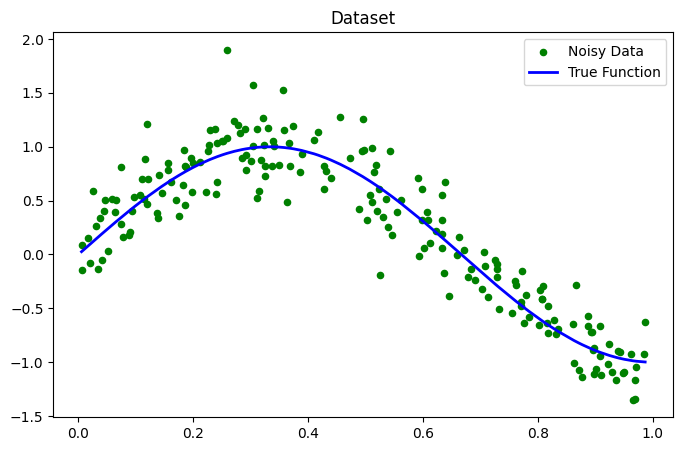

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='green', s=20, label='Noisy Data')
plt.plot(X, true_function(X), color='blue', linewidth=2, label='True Function')
plt.legend()
plt.title("Dataset")
plt.show()

In [6]:
tree = DecisionTreeRegressor(max_depth=None, random_state=42)
tree.fit(X_train,y_train)
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
train_mse = mean_squared_error(y_train,train_pred)
test_mse = mean_squared_error(y_test,test_pred)
print("Train MSE:",train_mse)
print("Test MSE:",test_mse)

Train MSE: 0.0
Test MSE: 0.12051834094061427


In [7]:
depth=[1,2,3,5,8,12,None]
train_errors=[]
test_errors=[]
for i in depth:
  model=DecisionTreeRegressor(max_depth=i,random_state=42)
  model.fit(X_train,y_train)
  train_pred=model.predict(X_train)
  test_pred=model.predict(X_test)
  train_errors.append(mean_squared_error(y_train,train_pred))
  test_errors.append(mean_squared_error(y_test,test_pred))

/tmp/ipykernel_5205/2847612570.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


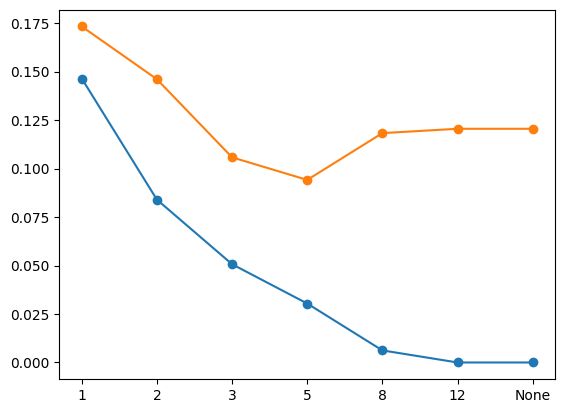

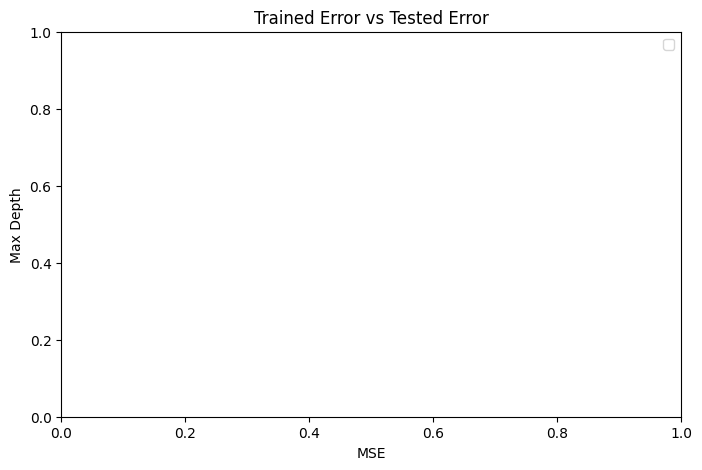

In [8]:
l=["1","2","3","5","8","12","None"]
plt.plot(l,train_errors,marker='o',label='Trained MSE')
plt.plot(l,test_errors,marker='o',label='Tested MSE')
plt.figure(figsize=(8,5))
plt.xlabel("MSE")
plt.ylabel("Max Depth")
plt.title("Trained Error vs Tested Error")
plt.legend()
plt.show()

In [13]:
r=RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
r.fit(X_train,y_train)
train_pred=r.predict(X_train)
test_pred=r.predict(X_test)
r_train=mean_squared_error(y_train,train_pred)
r_test=mean_squared_error(y_test,test_pred)
print("Random Forest Train MSE:",r_train)
print("Random Forest Test MSE:",r_test)
print("Decision Tree Train MSE:",train_mse)
print("Decision Tree Test MSE:",test_mse)


Random Forest Train MSE: 0.010460801202758248
Random Forest Test MSE: 0.1012343548315342
Decision Tree Train MSE: 0.0
Decision Tree Test MSE: 0.12051834094061427


In [26]:
tree=[1,5,10,20,50,100,200]
train_errors=[]
test_errors=[]
for i in tree:

    model=RandomForestRegressor(
        n_estimators=i,
        random_state=42
    )

    model.fit(X_train,y_train)
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)
    train_errors.append(mean_squared_error(y_train,train_pred))
    test_errors.append(mean_squared_error(y_test,test_pred))

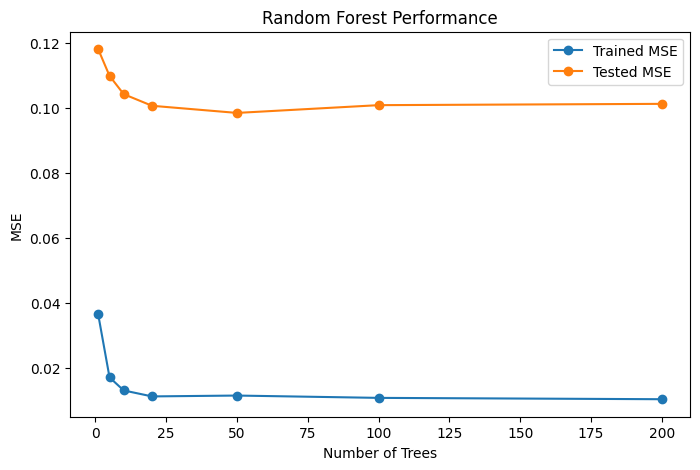

In [27]:
plt.figure(figsize=(8,5))
plt.plot(tree,train_errors,marker='o',label='Trained MSE')
plt.plot(tree,test_errors,marker='o',label='Tested MSE')

plt.xlabel("Number of Trees")
plt.ylabel("MSE")
plt.title("Random Forest Performance")
plt.legend()
plt.show()

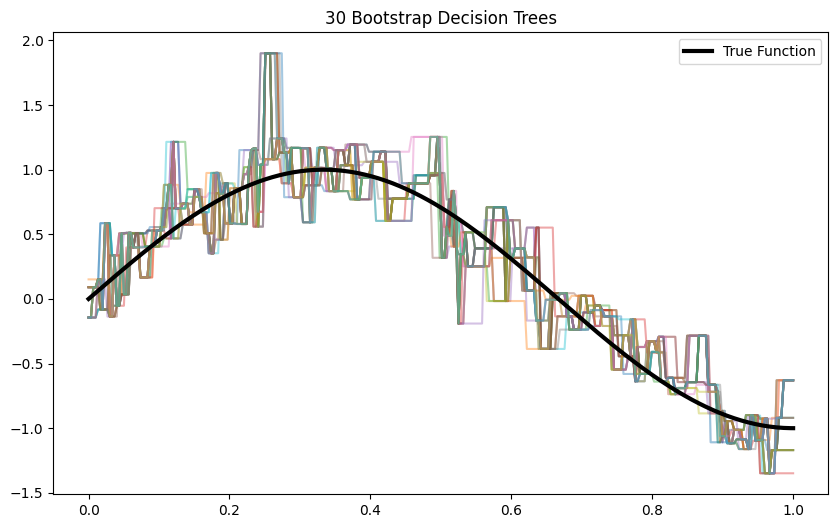

In [21]:
from sklearn.utils import resample

x_plot=np.linspace(0,1,300).reshape(-1,1)

plt.figure(figsize=(10,6))

for i in range(30):

    X_boot,y_boot=resample(
        X_train,
        y_train,
        replace=True,
        random_state=i
    )

    model=DecisionTreeRegressor(random_state=i)

    model.fit(X_boot,y_boot)

    pred=model.predict(x_plot)

    plt.plot(x_plot,pred,alpha=0.4)

plt.plot(x_plot,true_function(x_plot),color='black',linewidth=3,label='True Function')

plt.title("30 Bootstrap Decision Trees")
plt.legend()

plt.show()

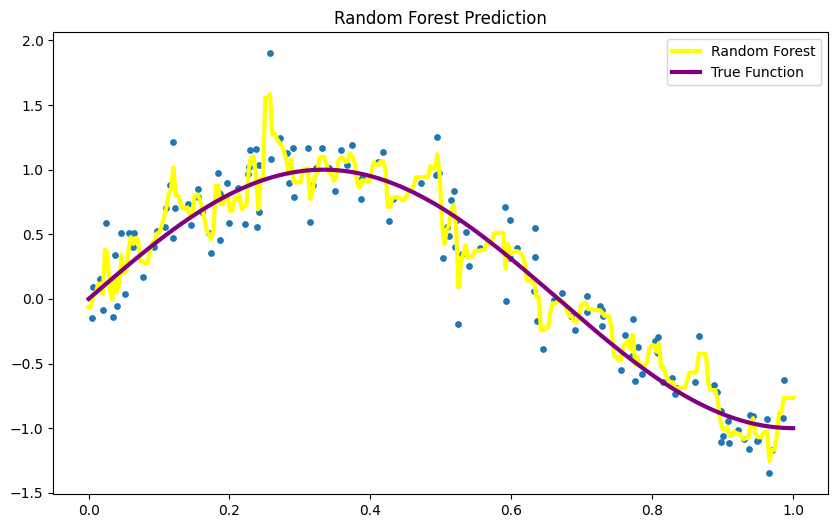

In [24]:
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred=rf.predict(x_plot)

plt.figure(figsize=(10,6))

plt.plot(x_plot,pred,color='yellow',linewidth=3,label='Random Forest')
plt.plot(x_plot,true_function(x_plot),color='purple',linewidth=3,label='True Function')

plt.scatter(X_train,y_train,s=15)

plt.legend()

plt.title("Random Forest Prediction")

plt.show()